Gradient Model — Stock Return Prediction & Ranking

Objective

To build a Gradient Boosting–based machine learning model to predict stock return direction and rank multiple stocks on a weekly basis for investment decision-making.

Specifically the model aims to:
Predict whether a stock’s return in the upcoming week will be positive (Up) or negative (Down).
Generate probability scores (P(Up)) for each stock, representing the likelihood of price increase.
Rank all stocks each week based on predicted probabilities to identify the top-performing stock.
Convert predictions into actionable Buy/Avoid signals for an investor.
Evaluate model performance using Accuracy, Confusion matrix, Ranking accuracy.
Simulate a real-world trading strategy through backtesting and compare it with a baseline market strategy.


Import Libraries


In [119]:
import pandas as pd
import numpy as np
import glob
import os

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print(" Libraries imported successfully")

 Libraries imported successfully


Load All Datasets

In [120]:
OUT_DIR = '../../data/results'
os.makedirs(OUT_DIR, exist_ok=True)

FILES = {
    'AAPL':  '../../data/Apple.csv',
    'MSFT':  '../../data/MSFT.csv',
    'GOOGL': '../../data/google.csv',
    'AMZN':  '../../data/Amazon.csv',
    'NVDA':  '../../data/NVIDIA.csv',
    'META':  '../../data/META.csv',
    'TSLA':  '../../data/TSLA.csv',
    'JPM':   '../../data/JPM.csv',
    'GS':    '../../data/GSach.csv',
    'JNJ':   '../../data/JNJ.csv',
    'PFE':   '../../data/PFE.csv',
    'XOM':   '../../data/XOM.csv',
    'CVX':   '../../data/CVX.csv',
    'WMT':   '../../data/WMT.csv',
    'BA':    '../../data/BA.csv',
}

data = {}

for name, path in FILES.items():
    df = pd.read_csv(path)
    
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
    df.sort_index(inplace=True)
    
    data[name] = df

    # debug prints INSIDE loop
    print(f"\n Loaded: {name}")
    print(df.head(2))

print("\n Total datasets loaded:", len(data))


 Loaded: AAPL
             Open   High    Low  Close  Adj Close       Volume
Date                                                          
2015-01-02  27.85  27.86  26.84  27.33      24.21  212,818,400
2015-01-05  27.07  27.16  26.35  26.56      23.53  257,142,000

 Loaded: MSFT
             Open   High    Low  Close   Adj Close       Volume
Date                                                           
2015-01-02  46.66  47.42  46.54   46.76       39.77  27,913,900
2015-01-05  46.37  46.73  46.25   46.33       39.40  39,673,900

 Loaded: GOOGL
             Open   High    Low  Close   Adj Close       Volume
Date                                                           
2015-01-02  26.63  26.79  26.39   26.48       26.28  26,480,000
2015-01-05  26.36  26.40  25.89   25.97       25.78  41,182,000

 Loaded: AMZN
             Open   High    Low  Close   Adj Close       Volume
Date                                                           
2015-01-02  15.63  15.74  15.35   15.43       1

/var/folders/y7/m34ty1kx4l937c3yb57w1g0c0000gn/T/ipykernel_44388/3694126030.py:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


FEATURE ENGINEERING

In [124]:
def build_features(df):
    
    df = df.loc[:, ~df.columns.duplicated()]
    
    if isinstance(df['Close'], pd.DataFrame):
        df['Close'] = df['Close'].iloc[:, 0]
    
    w = df.resample('W-FRI').last()
    
    # Weekly return
    w['Weekly_Return'] = w['Close'].pct_change() * 100
    
    # Lags (features)
    w['lag1'] = w['Weekly_Return'].shift(1)
    w['lag2'] = w['Weekly_Return'].shift(2)
    
    # Moving averages
    w['ma4'] = w['Weekly_Return'].rolling(4).mean().shift(1)
    w['ma8'] = w['Weekly_Return'].rolling(8).mean().shift(1)
    
    # Volatility
    w['vol'] = w['Weekly_Return'].rolling(4).std().shift(1)
    
    # TARGET (very important)
    w['Target'] = (w['Weekly_Return'] > 0).astype(int)
    
    return w

Combine ALL STOCKS 

In [125]:
for stock in data:
    print(stock, data[stock].columns.tolist())

AAPL ['Open', 'High', 'Low', 'Close', 'Volume']
MSFT ['Open', 'High', 'Low', 'Close', 'Volume']
GOOGL ['Open', 'High', 'Low', 'Close', 'Volume']
AMZN ['Open', 'High', 'Low', 'Close', 'Volume']
NVDA ['Open', 'High', 'Low', 'Close', 'Volume']
META ['Open', 'High', 'Low', 'Close', 'Volume']
TSLA ['Open', 'High', 'Low', 'Close', 'Volume']
JPM ['Open', 'High', 'Low', 'Close', 'Volume']
GS ['Open', 'High', 'Low', 'Close', 'Volume']
JNJ ['Open', 'High', 'Low', 'Close', 'Volume']
PFE ['Open', 'High', 'Low', 'Close', 'Volume']
XOM ['Open', 'High', 'Low', 'Close', 'Volume']
CVX ['Open', 'High', 'Low', 'Close', 'Volume']
WMT ['Open', 'High', 'Low', 'Close', 'Volume']
BA ['Open', 'High', 'Low', 'Close', 'Volume']


In [126]:
for name, path in FILES.items():
    df = pd.read_csv(path)

    
    df.columns = df.columns.str.strip()

   
    if 'Adj Close' in df.columns:
        df.rename(columns={'Adj Close': 'Close'}, inplace=True)
    elif 'close' in df.columns:
        df.rename(columns={'close': 'Close'}, inplace=True)

    
    df = df.loc[:, ~df.columns.duplicated()]

    if 'Close' not in df.columns:
        print(f" Skipping {name} — no Close column")
        continue

    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
    df.sort_index(inplace=True)

    data[name] = df

    print(f" Loaded {name}")

 Loaded AAPL
 Loaded MSFT
 Loaded GOOGL
 Loaded AMZN
 Loaded NVDA
 Loaded META
 Loaded TSLA
 Loaded JPM
 Loaded GS
 Loaded JNJ
 Loaded PFE
 Loaded XOM
 Loaded CVX
 Loaded WMT
 Loaded BA


/var/folders/y7/m34ty1kx4l937c3yb57w1g0c0000gn/T/ipykernel_44388/3731362450.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


In [127]:
processed = []

for stock in data:
    
    df_raw = data[stock].copy()

    if 'Close' not in df_raw.columns:
        print(f" Skipping {stock} — no Close column")
        continue
    
    df = build_features(df_raw)
    
    if len(df) < 50:
        print(f" Skipping {stock} (not enough data)")
        continue
    
    df['Stock'] = stock
    
    print(f" {stock} processed → rows:", len(df))
    print(df[['Weekly_Return','lag1','Target']].head(2))
    
    processed.append(df)

combined = pd.concat(processed)

print("\n Combined dataset shape:", combined.shape)

 AAPL processed → rows: 583
            Weekly_Return  lag1  Target
Date                                   
2015-01-02            NaN   NaN       0
2015-01-09       2.451518   NaN       1
 MSFT processed → rows: 583
            Weekly_Return  lag1  Target
Date                                   
2015-01-02            NaN   NaN       0
2015-01-09       0.919589   NaN       1
 GOOGL processed → rows: 583
            Weekly_Return  lag1  Target
Date                                   
2015-01-02            NaN   NaN       0
2015-01-09      -5.438066   NaN       0
 AMZN processed → rows: 583
            Weekly_Return  lag1  Target
Date                                   
2015-01-02            NaN   NaN       0
2015-01-09      -3.758911   NaN       0
 NVDA processed → rows: 583
            Weekly_Return  lag1  Target
Date                                   
2015-01-02            NaN   NaN       0
2015-01-09            0.0   NaN       0
 META processed → rows: 583
            Weekly_Return  lag1

CROSS-SECTIONAL FEATURES

In [128]:
combined['mean_return'] = combined.groupby(combined.index)['lag1'].transform('mean')
combined['rank'] = combined.groupby(combined.index)['lag1'].rank()

combined = combined.dropna()

In [129]:
print(combined['Stock'].unique())

['AAPL' 'MSFT' 'GOOGL' 'AMZN' 'NVDA' 'META' 'TSLA' 'JPM' 'GS' 'JNJ' 'PFE'
 'XOM' 'CVX' 'WMT' 'BA']


In [130]:
print(combined.groupby('Stock').head(2))

              Open    High     Low   Close       Volume  Weekly_Return  \
Date                                                                     
2015-03-06    32.1   32.34   31.57   31.65  291,368,400      -1.463263   
2015-03-13    31.1   31.35   30.65   30.90  207,309,200      -2.369668   
2015-03-06    43.0   43.11   42.15   42.36   36,248,800      -3.397948   
2015-03-13    40.7   41.47   40.61   41.38   58,007,700      -2.313503   
2015-03-06    29.1   29.14   28.60   28.65   37,592,000       1.848560   
2015-03-13   27.96   28.22   27.52   27.65   35,428,000      -3.490401   
2015-03-06   19.28   19.35   18.94   19.00   52,540,000      -0.052604   
2015-03-13   18.58   18.70   18.33   18.53   52,234,000      -2.473684   
2015-03-06    0.57    0.57    0.56    0.56  257,392,000       1.818182   
2015-03-13    0.56    0.57    0.56    0.57  359,288,000       1.785714   
2015-03-06    80.9   81.33   79.83   80.01   24,488,600       1.316956   
2015-03-13    78.6   79.38   77.68   7

In [131]:
combined = combined.sort_values(['Date','Stock'])

 TRAIN / VAL / TEST SPLIT

In [132]:
train = combined[combined.index < "2024-01-01"]
val = combined[(combined.index >= "2024-01-01") & (combined.index < "2025-01-01")]
test = combined[combined.index >= "2025-01-01"]

print("\n Train size:", train.shape)
print(" Val size:", val.shape)
print(" Test size:", test.shape)


 Train size: (6915, 15)
 Val size: (780, 15)
 Test size: (915, 15)


Model Training

In [133]:
features = ['lag1','lag2','ma4','ma8','vol','mean_return','rank']

X_train = train[features]
y_train = train['Target']

X_test = test[features]
y_test = test['Target']

model = GradientBoostingClassifier(n_estimators=200)

model.fit(X_train, y_train)

print("\n Model trained successfully")



 Model trained successfully


Predictions

In [134]:
test['Prob_Up'] = model.predict_proba(X_test)[:,1]
test['Pred'] = model.predict(X_test)

print("\n Predictions sample:")
print(test[['Stock','Prob_Up','Pred']].head())



 Predictions sample:
            Stock   Prob_Up  Pred
Date                             
2025-01-03   AAPL  0.458682     0
2025-01-03   AMZN  0.538841     1
2025-01-03     BA  0.585686     1
2025-01-03    CVX  0.508853     1
2025-01-03  GOOGL  0.606905     1


/var/folders/y7/m34ty1kx4l937c3yb57w1g0c0000gn/T/ipykernel_44388/1256054395.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Prob_Up'] = model.predict_proba(X_test)[:,1]
/var/folders/y7/m34ty1kx4l937c3yb57w1g0c0000gn/T/ipykernel_44388/1256054395.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Pred'] = model.predict(X_test)


Accuracy

In [135]:
accuracy = accuracy_score(y_test, test['Pred'])
print("\n Accuracy:", accuracy)


 Accuracy: 0.5366120218579234


CONFUSION MATRIX

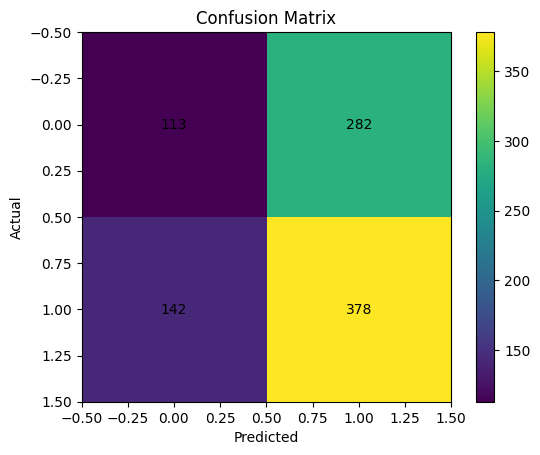

In [136]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, test['Pred'])

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.colorbar()
plt.show()

PROBABILITY OVER TIME



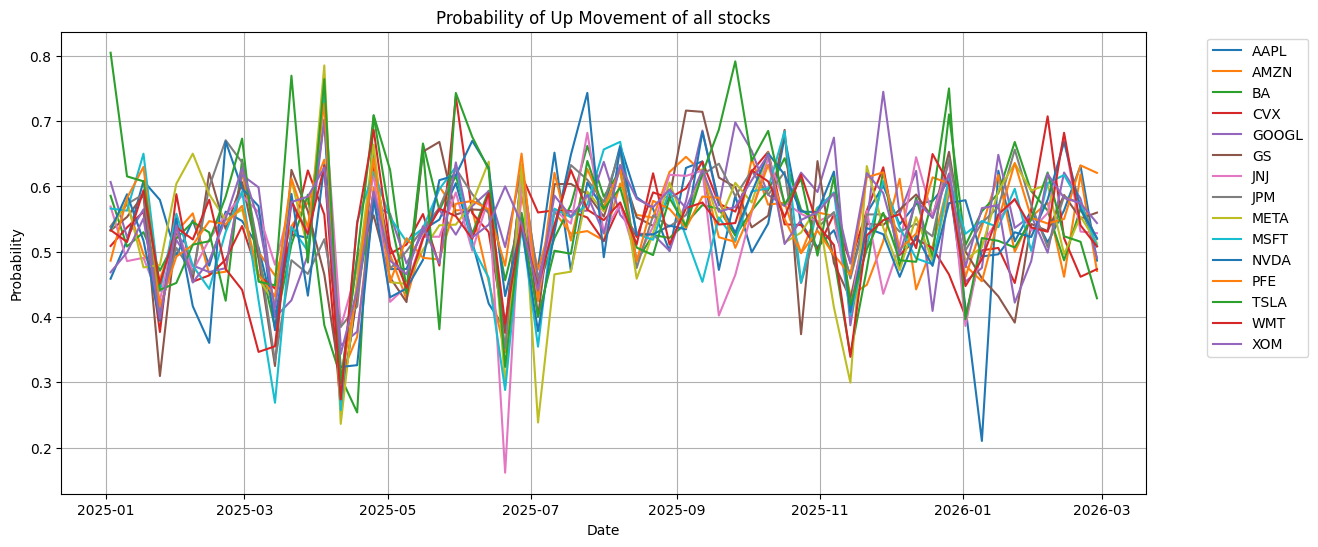

In [137]:
plt.figure(figsize=(14,6))

for stock in test['Stock'].unique():  # remove [:5] if needed
    temp = test[test['Stock'] == stock]
    plt.plot(temp.index, temp['Prob_Up'], label=stock)

plt.title("Probability of Up Movement of all stocks")
plt.xlabel("Date")
plt.ylabel("Probability")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()

plt.show()

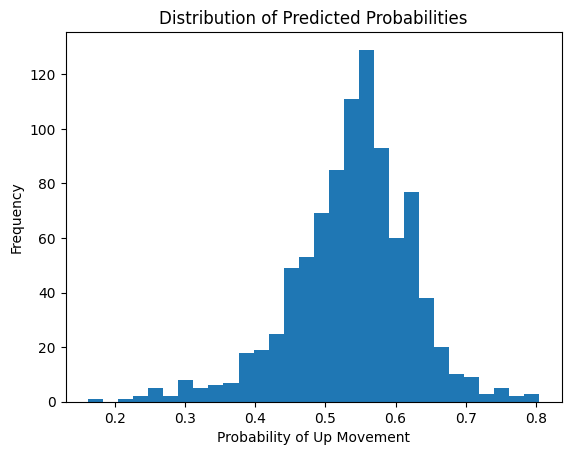

In [138]:
plt.figure()
plt.hist(test['Prob_Up'], bins=30)
plt.title("Distribution of Predicted Probabilities")
plt.xlabel("Probability of Up Movement")
plt.ylabel("Frequency")
plt.show()

BUY / SELL SIGNALS

In [139]:
print(test['Stock'].unique())

['AAPL' 'AMZN' 'BA' 'CVX' 'GOOGL' 'GS' 'JNJ' 'JPM' 'META' 'MSFT' 'NVDA'
 'PFE' 'TSLA' 'WMT' 'XOM']


In [140]:
threshold = 0.6

test['Signal'] = np.where(
    test['Prob_Up'] > threshold, "BUY",
    np.where(test['Prob_Up'] < (1 - threshold), "SELL", "HOLD")
)

/var/folders/y7/m34ty1kx4l937c3yb57w1g0c0000gn/T/ipykernel_44388/3605961542.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Signal'] = np.where(


In [141]:
print(test[['Stock','Prob_Up','Signal']].head(15))

            Stock   Prob_Up Signal
Date                              
2025-01-03   AAPL  0.458682   HOLD
2025-01-03   AMZN  0.538841   HOLD
2025-01-03     BA  0.585686   HOLD
2025-01-03    CVX  0.508853   HOLD
2025-01-03  GOOGL  0.606905    BUY
2025-01-03     GS  0.532701   HOLD
2025-01-03    JNJ  0.569279   HOLD
2025-01-03    JPM  0.538331   HOLD
2025-01-03   META  0.532007   HOLD
2025-01-03   MSFT  0.566179   HOLD
2025-01-03   NVDA  0.533137   HOLD
2025-01-03    PFE  0.486288   HOLD
2025-01-03   TSLA  0.804903    BUY
2025-01-03    WMT  0.533290   HOLD
2025-01-03    XOM  0.468583   HOLD


FEATURE IMPORTANCE


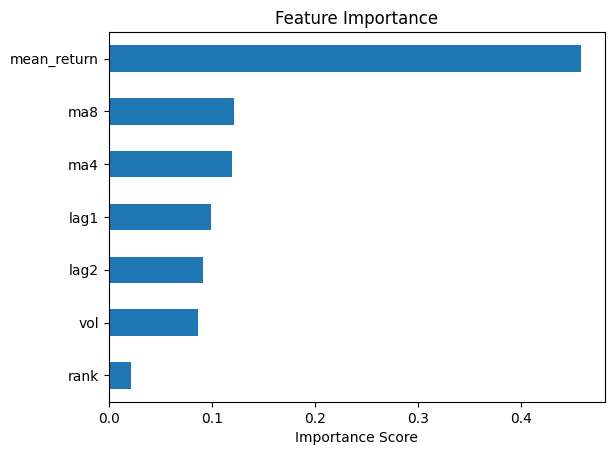

In [142]:
import pandas as pd

importances = model.feature_importances_
features = X_train.columns

feat_imp = pd.Series(importances, index=features).sort_values()

plt.figure()
feat_imp.plot(kind='barh')
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()

WEEKLY RANKING

In [143]:
test['Rank'] = test.groupby(test.index)['Prob_Up'].rank(ascending=False)

top = test[test['Rank'] == 1]

print("\n Top stock each week:")
print(top[['Stock','Prob_Up']].head())


 Top stock each week:
           Stock   Prob_Up
Date                      
2025-01-03  TSLA  0.804903
2025-01-10  TSLA  0.615479
2025-01-17  MSFT  0.650224
2025-01-24  AAPL  0.579393
2025-01-31  META  0.604250


/var/folders/y7/m34ty1kx4l937c3yb57w1g0c0000gn/T/ipykernel_44388/2092847064.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Rank'] = test.groupby(test.index)['Prob_Up'].rank(ascending=False)


RANKING HEATMAP

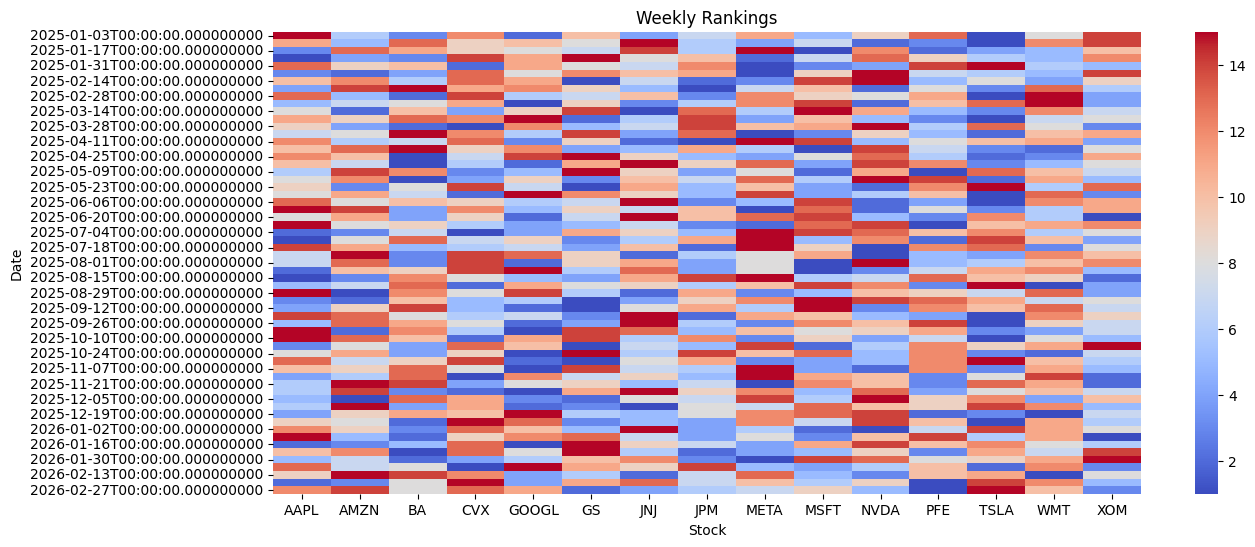

In [144]:
pivot = test.pivot_table(index=test.index, columns='Stock', values='Rank')

plt.figure(figsize=(14,6))
sns.heatmap(pivot, cmap='coolwarm')
plt.title("Weekly Rankings")
plt.show()


Predictions vs Actual (Classification View)

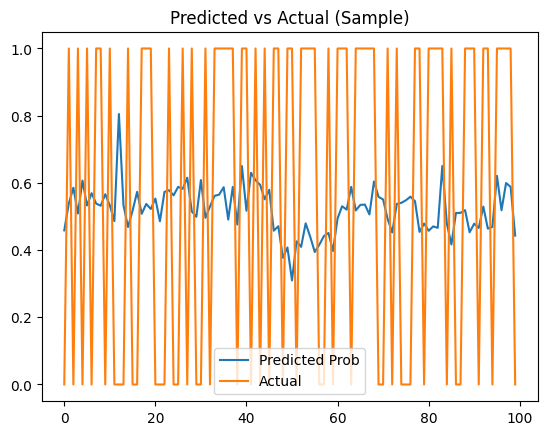

In [145]:
plt.figure()

plt.plot(test['Prob_Up'].values[:100], label='Predicted Prob')
plt.plot(test['Target'].values[:100], label='Actual')

plt.title("Predicted vs Actual (Sample)")
plt.legend()
plt.show()

Model Performance

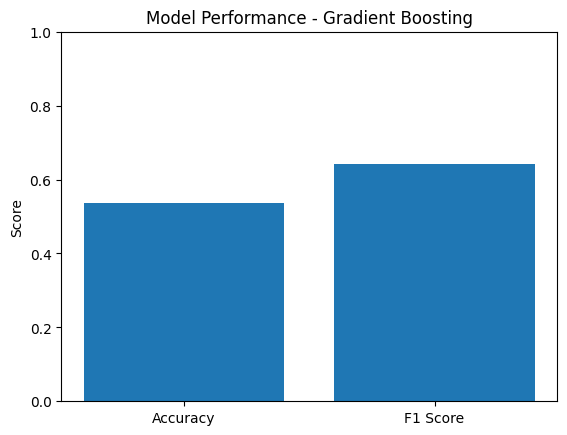

In [146]:
import matplotlib.pyplot as plt

metrics = ['Accuracy', 'F1 Score']
values = [accuracy, f1]

plt.figure()
plt.bar(metrics, values)
plt.title("Model Performance - Gradient Boosting")
plt.ylabel("Score")
plt.ylim(0,1)
plt.show()

Generate Predictions for ALL Stocks

In [147]:
prediction_table = test[['Stock', 'Prob_Up', 'Pred', 'Weekly_Return']].copy()

print(prediction_table.head(10))

            Stock   Prob_Up  Pred  Weekly_Return
Date                                            
2025-01-03   AAPL  0.458682     0      -4.785007
2025-01-03   AMZN  0.538841     1       0.196648
2025-01-03     BA  0.585686     1      -5.987162
2025-01-03    CVX  0.508853     1       2.673611
2025-01-03  GOOGL  0.606905     1      -0.503216
2025-01-03     GS  0.532701     1       0.685550
2025-01-03    JNJ  0.569279     1      -0.592899
2025-01-03    JPM  0.538331     1       0.874902
2025-01-03   META  0.532007     1       0.803588
2025-01-03   MSFT  0.566179     1      -1.667712


Get Top Stock Prediction PER DAY

In [148]:
top_predictions = []

dates = test.index.unique()

for date in dates:
    
    temp = test.loc[date]

    if isinstance(temp, pd.Series) or len(temp) < 2:
        continue

    temp = temp.reset_index(drop=True)

    best_pred = temp.loc[temp['Prob_Up'].idxmax()]
    best_actual = temp.loc[temp['Weekly_Return'].idxmax()]

    top_predictions.append({
        'Date': date,
        'Predicted_Best_Stock': best_pred['Stock'],
        'Actual_Best_Stock': best_actual['Stock'],
        'Predicted_Prob': best_pred['Prob_Up'],
        'Actual_Return': best_actual['Weekly_Return']
    })

top_df = pd.DataFrame(top_predictions)

print(top_df.head())

        Date Predicted_Best_Stock Actual_Best_Stock  Predicted_Prob  \
0 2025-01-03                 TSLA              NVDA        0.804903   
1 2025-01-10                 TSLA               CVX        0.615479   
2 2025-01-17                 MSFT                GS        0.650224   
3 2025-01-24                 AAPL              META        0.579393   
4 2025-01-31                 META              META        0.604250   

   Actual_Return  
0       5.444858  
1       3.577951  
2      11.775000  
3       5.666074  
4       6.438709  


Show Top 3 Stocks Per Day

In [149]:
top3_list = []

for date in dates:
    
    temp = test.loc[date]

    if isinstance(temp, pd.Series) or len(temp) < 2:
        continue

    temp = temp.reset_index(drop=True)

    top3 = temp.sort_values(by='Prob_Up', ascending=False).head(3)

    for _, row in top3.iterrows():
        top3_list.append({
            'Date': date,
            'Stock': row['Stock'],
            'Prob_Up': row['Prob_Up']
        })

top3_df = pd.DataFrame(top3_list)

print(top3_df.head(10))

        Date  Stock   Prob_Up
0 2025-01-03   TSLA  0.804903
1 2025-01-03  GOOGL  0.606905
2 2025-01-03     BA  0.585686
3 2025-01-10   TSLA  0.615479
4 2025-01-10   NVDA  0.588076
5 2025-01-10    PFE  0.582214
6 2025-01-17   MSFT  0.650224
7 2025-01-17    PFE  0.629991
8 2025-01-17   AAPL  0.608291
9 2025-01-24   AAPL  0.579393


Future Predictions

In [152]:
import pandas as pd
import numpy as np


df.columns = df.columns.str.strip().str.lower()

if 'close' in df.columns:
    price_col = 'close'
elif 'adj close' in df.columns:
    price_col = 'adj close'
else:
    raise ValueError("No valid price column found")

def create_features(df, price_col):
    df = df.copy()

    df['lag1'] = df[price_col].pct_change(1)
    df['lag2'] = df[price_col].pct_change(2)

    df['ma4'] = df[price_col].rolling(4).mean()
    df['ma8'] = df[price_col].rolling(8).mean()

    df['vol'] = df[price_col].rolling(4).std()
    df['mean_return'] = df[price_col].pct_change().rolling(4).mean()

    return df

df_feat = create_features(df, price_col)



# rank feature (safe version)
if 'weekly_return' in df_feat.columns:
    df_feat['rank'] = df_feat['weekly_return'].rank()
else:
    df_feat['rank'] = 0   # fallback (won’t break code)

model_features = model.feature_names_in_

latest_data = df_feat.iloc[[-1]].copy()


for col in model_features:
    if col not in latest_data.columns:
        latest_data[col] = 0

# reorder columns EXACTLY like training
latest_data = latest_data[model_features]


latest_data = latest_data.fillna(0)


future_prob = model.predict_proba(latest_data)[0][1]

print("Next Prediction Probability:", round(future_prob, 3))

if future_prob > 0.5:
    print("Prediction: UP ")
else:
    print("Prediction: DOWN ")

Next Prediction Probability: 0.622
Prediction: UP 


Full Prediction Matrix

In [153]:
pivot_preds = test.pivot_table(
    index=test.index,
    columns='Stock',
    values='Prob_Up'
)

print(pivot_preds.head())

Stock           AAPL      AMZN        BA       CVX     GOOGL        GS  \
Date                                                                     
2025-01-03  0.458682  0.538841  0.585686  0.508853  0.606905  0.532701   
2025-01-10  0.517453  0.573373  0.508018  0.537236  0.522349  0.553305   
2025-01-17  0.608291  0.496003  0.529934  0.561405  0.564981  0.587098   
2025-01-24  0.579393  0.457812  0.470932  0.377081  0.407684  0.309618   
2025-01-31  0.493923  0.530484  0.520361  0.588141  0.517967  0.534492   

Stock            JNJ       JPM      META      MSFT      NVDA       PFE  \
Date                                                                     
2025-01-03  0.569279  0.538331  0.532007  0.566179  0.533137  0.486288   
2025-01-10  0.485648  0.573099  0.578174  0.562945  0.588076  0.582214   
2025-01-17  0.490759  0.588068  0.476020  0.650224  0.517092  0.629991   
2025-01-24  0.426060  0.409568  0.479633  0.439693  0.394255  0.416108   
2025-01-31  0.535485  0.506041  0.604

Investment Strategy

In [154]:
strategy_returns = []

for date in dates:
    
    temp = test.loc[date]

    if isinstance(temp, pd.Series) or len(temp) < 2:
        continue

    temp = temp.reset_index(drop=True)

    best_stock = temp.loc[temp['Prob_Up'].idxmax()]
    
    strategy_returns.append(best_stock['Weekly_Return'])

print("Strategy Return:", sum(strategy_returns))

Strategy Return: 16.285553323244745


Cumulative Strategy vs Market

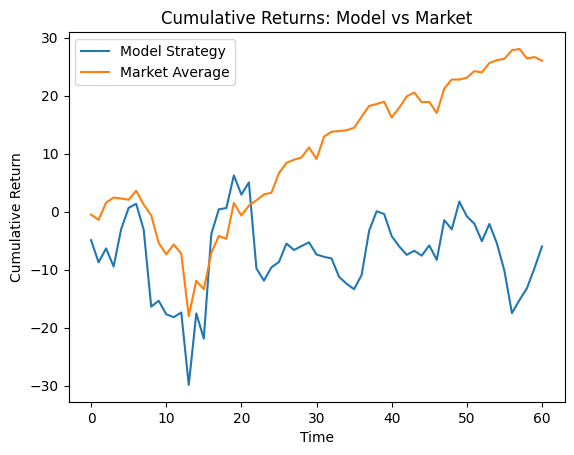

In [100]:
import matplotlib.pyplot as plt
import numpy as np

strategy_returns = []
market_returns = []

dates = test.index.unique()

for date in dates:
    temp = test.loc[date]

    if isinstance(temp, pd.Series) or len(temp) < 2:
        continue

    temp = temp.reset_index(drop=True)

    # Model pick
    best = temp.loc[temp['Prob_Up'].idxmax()]
    strategy_returns.append(best['Weekly_Return'])

    # Market average
    market_returns.append(temp['Weekly_Return'].mean())

# cumulative returns
strategy_cum = np.cumsum(strategy_returns)
market_cum = np.cumsum(market_returns)

plt.figure()
plt.plot(strategy_cum, label='Model Strategy')
plt.plot(market_cum, label='Market Average')
plt.title("Cumulative Returns: Model vs Market")
plt.xlabel("Time")
plt.ylabel("Cumulative Return")
plt.legend()
plt.show()

Top Stock Prediction Accuracy

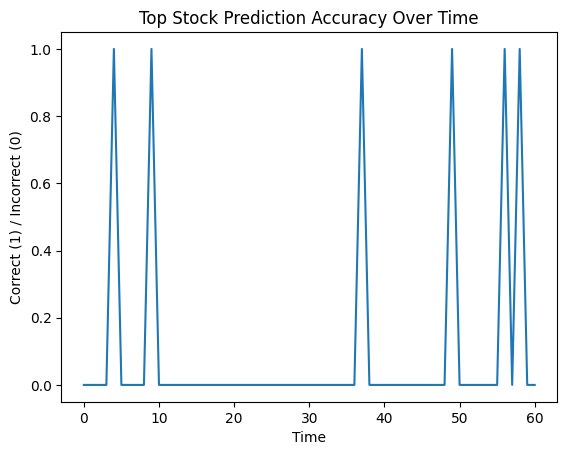

In [155]:
accuracy_series = []

for date in dates:
    temp = test.loc[date]

    if isinstance(temp, pd.Series) or len(temp) < 2:
        continue

    temp = temp.reset_index(drop=True)

    pred = temp.loc[temp['Prob_Up'].idxmax(), 'Stock']
    actual = temp.loc[temp['Weekly_Return'].idxmax(), 'Stock']

    accuracy_series.append(1 if pred == actual else 0)

plt.figure()
plt.plot(accuracy_series)
plt.title("Top Stock Prediction Accuracy Over Time")
plt.xlabel("Time")
plt.ylabel("Correct (1) / Incorrect (0)")
plt.show()

CSV

In [163]:
import pandas as pd

rows = []
dates = test.index.unique()

for date in dates:
    
    temp = test.loc[date]

    if isinstance(temp, pd.Series) or len(temp) < 2:
        continue

    temp = temp.reset_index(drop=True)

    # sort predictions
    temp_sorted = temp.sort_values(by='Prob_Up', ascending=False)

    top3 = temp_sorted.head(3)
    actual_best = temp.loc[temp['Weekly_Return'].idxmax()]

    rows.append({
        "Date": date,

        "Predicted #1": top3.iloc[0]['Stock'],
        "Prob #1": round(top3.iloc[0]['Prob_Up'], 3),

        "Predicted #2": top3.iloc[1]['Stock'],
        "Prob #2": round(top3.iloc[1]['Prob_Up'], 3),

        "Predicted #3": top3.iloc[2]['Stock'],
        "Prob #3": round(top3.iloc[2]['Prob_Up'], 3),

        "Actual Best": actual_best['Stock'],
        "Actual Return": round(actual_best['Weekly_Return'], 3),

        "Correct": "✔" if top3.iloc[0]['Stock'] == actual_best['Stock'] else "✘"
    })

final_table = pd.DataFrame(rows)

# sort by date
final_table = final_table.sort_values(by="Date")

final_table.to_csv("gradient_visual_table.csv", index=False)

print("Clean structured CSV saved!")

Clean structured CSV saved!


Heatmap Of Prediction

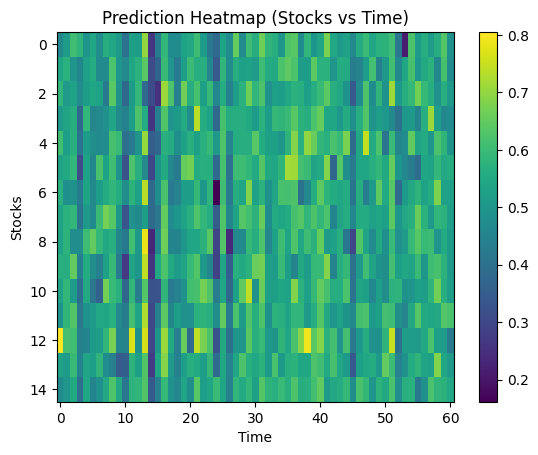

In [157]:
import matplotlib.pyplot as plt

pivot = test.pivot_table(
    index=test.index,
    columns='Stock',
    values='Prob_Up'
)

plt.figure()
plt.imshow(pivot.T, aspect='auto')
plt.title("Prediction Heatmap (Stocks vs Time)")
plt.xlabel("Time")
plt.ylabel("Stocks")
plt.colorbar()
plt.show()

Overall Accuracy & F1 Score


In [158]:
from sklearn.metrics import f1_score

accuracy = accuracy_score(y_test, test['Pred'])
f1 = f1_score(y_test, test['Pred'])

print("Accuracy:", round(accuracy, 3))
print("F1 Score:", round(f1, 3))

Accuracy: 0.537
F1 Score: 0.641


Train/ VAliDation/ Test Size


In [159]:
print("Train Size:", X_train.shape)
print(" Val size:", val.shape)
print("Test Size:", X_test.shape)

Train Size: (6915, 7)
 Val size: (780, 15)
Test Size: (915, 7)


Ranking Accuracy

Ranking Accuracy: 0.098


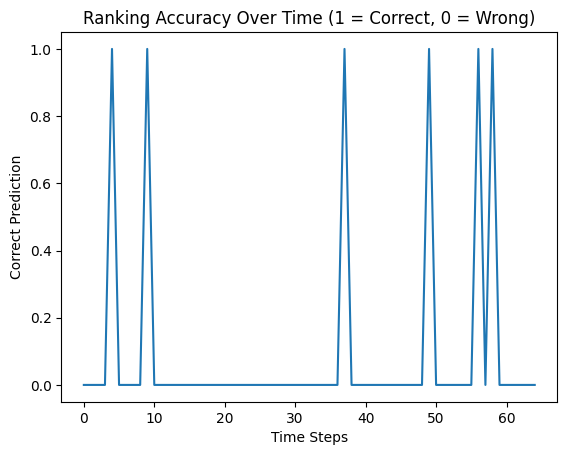

In [164]:
correct = 0
valid_dates = 0

dates = test.index.unique()

for date in dates:
    
    temp = test.loc[date]

   
    if isinstance(temp, pd.Series) or len(temp) < 2:
        continue

    
    temp = temp.reset_index(drop=True)

    pred_best = temp.loc[temp['Prob_Up'].idxmax(), 'Stock']
    actual_best = temp.loc[temp['Weekly_Return'].idxmax(), 'Stock']

    if pred_best == actual_best:
        correct += 1

    valid_dates += 1

ranking_accuracy = correct / valid_dates

print("Ranking Accuracy:", round(ranking_accuracy, 3))

correct_list.append(1 if pred_best == actual_best else 0)

plt.figure()
plt.plot(correct_list)
plt.title("Ranking Accuracy Over Time (1 = Correct, 0 = Wrong)")
plt.xlabel("Time Steps")
plt.ylabel("Correct Prediction")
plt.show()



Rows, Columns, Date Range

In [161]:
print("Dataset shape:", combined.shape)
print("Number of rows:", combined.shape[0])
print("Number of columns:", combined.shape[1])

print("Date range:", combined.index.min(), "to", combined.index.max())

Dataset shape: (8610, 15)
Number of rows: 8610
Number of columns: 15
Date range: 2015-03-06 00:00:00 to 2026-02-27 00:00:00


In this project, a Gradient Boosting Classifier is used to predict whether a stock's price will increase in the next time period. The model is trained on engineered financial features such as:
Lagged returns (previous price movements)
Moving averages (short-term and long-term trends)
Volatility (risk and variability in returns)
Mean returns and ranking-based features

Gradient Boosting is an ensemble learning method that builds multiple decision trees sequentially. Each new tree is trained to correct the errors made by the previous trees. This iterative process allows the model to learn complex, non-linear patterns present in financial data.

Unlike traditional models such as ARIMA, which assume linear relationships and focus only on time-series structure, Gradient Boosting can capture interactions between multiple features and adapt to changing market conditions.

The model outputs a probability score (Prob_Up) representing the likelihood that a stock will move upward. Instead of using only binary predictions (0 or 1), these probabilities are used to rank all stocks for each date.

This ranking approach is important because: Financial decision-making is relative (choosing best stock).
It allows comparison across multiple stocks at the same time
It supports portfolio selection strategies

Based on the predicted probabilities the model identifies the top-ranked stock for each day compares it with the actual best-performing stock computes ranking accuracy to evaluate performance.

The model is evaluated using multiple metrics:
Accuracy: Measures overall classification correctness
F1 Score: Balances precision and recall for classification
Ranking Accuracy: Measures how often the top predicted stock matches the actual best-performing stock

Reasons for choosing Gradient Boosting:

Handles Non-Linearity: Financial markets are highly complex and non-linear. Gradient Boosting captures these relationships effectively.

Strong Predictive Performance: It generally outperforms traditional statistical models in classification tasks involving structured data.

Robust to Noise: Stock market data is noisy and volatile. Boosting methods iteratively reduce errors and improve stability.

Feature Importance: The model provides importance scores, helping identify key drivers such as momentum, volatility, and trends.

Probability-Based Output: Unlike many models, it produces probabilities which allow ranking of stocks instead of just classification.

Strategy-Oriented: The model directly supports a practical investment strategy by selecting top-ranked stocks based on predicted probabilities.

Overall, the Gradient Boosting model enhances both predictive accuracy and decision-making capability, making it a suitable choice for stock prediction and ranking tasks.
